<h1> Testing the spred of wells in a lease <h1>

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = "../../data/raw/texas/cleaned_data/lease_well_coordinates.geoparquet"
path2 = "../../data/raw/texas/cleaned_data/tot_prod_with_lease_coord.parquet"

gdf = gpd.read_parquet(path)

gdf.columns


Index(['oil_gas_code', 'district_no', 'lease_no', 'well_no', 'api_county_code',
       'api_unique_no', 'county_name', 'wellbore_location_code', 'api_no',
       'oil_gas_code_norm', 'district_no_norm', 'lease_no_norm', 'lease_key',
       'api8_from_components', 'api8_from_api_no', 'api8', 'longitude',
       'latitude', 'geometry', 'SOURCE_ZIP', 'SOURCE_SHP', 'well_layer_type',
       'API', 'API10', 'APINUM', 'LAT27', 'LONG27', 'LAT83', 'LONG83',
       'RELIAB', 'SYMNUM', 'WELLID'],
      dtype='str')

In [4]:
gdf = gdf.drop(columns=['oil_gas_code','api_county_code',
       'api_unique_no', 'county_name', 'wellbore_location_code', 'api_no',
       'oil_gas_code_norm', 'district_no_norm', 'lease_no_norm','api8_from_components', 'api8_from_api_no','SOURCE_ZIP', 'SOURCE_SHP', 'well_layer_type',
       'API', 'API10', 'APINUM', 'LAT27', 'LONG27', 'LAT83', 'LONG83',
       'RELIAB', 'SYMNUM', 'WELLID']).copy()

In [5]:
gdf[['latitude','longitude']]=gdf[['latitude','longitude']].replace({np.nan : pd.NA})

<Axes: >

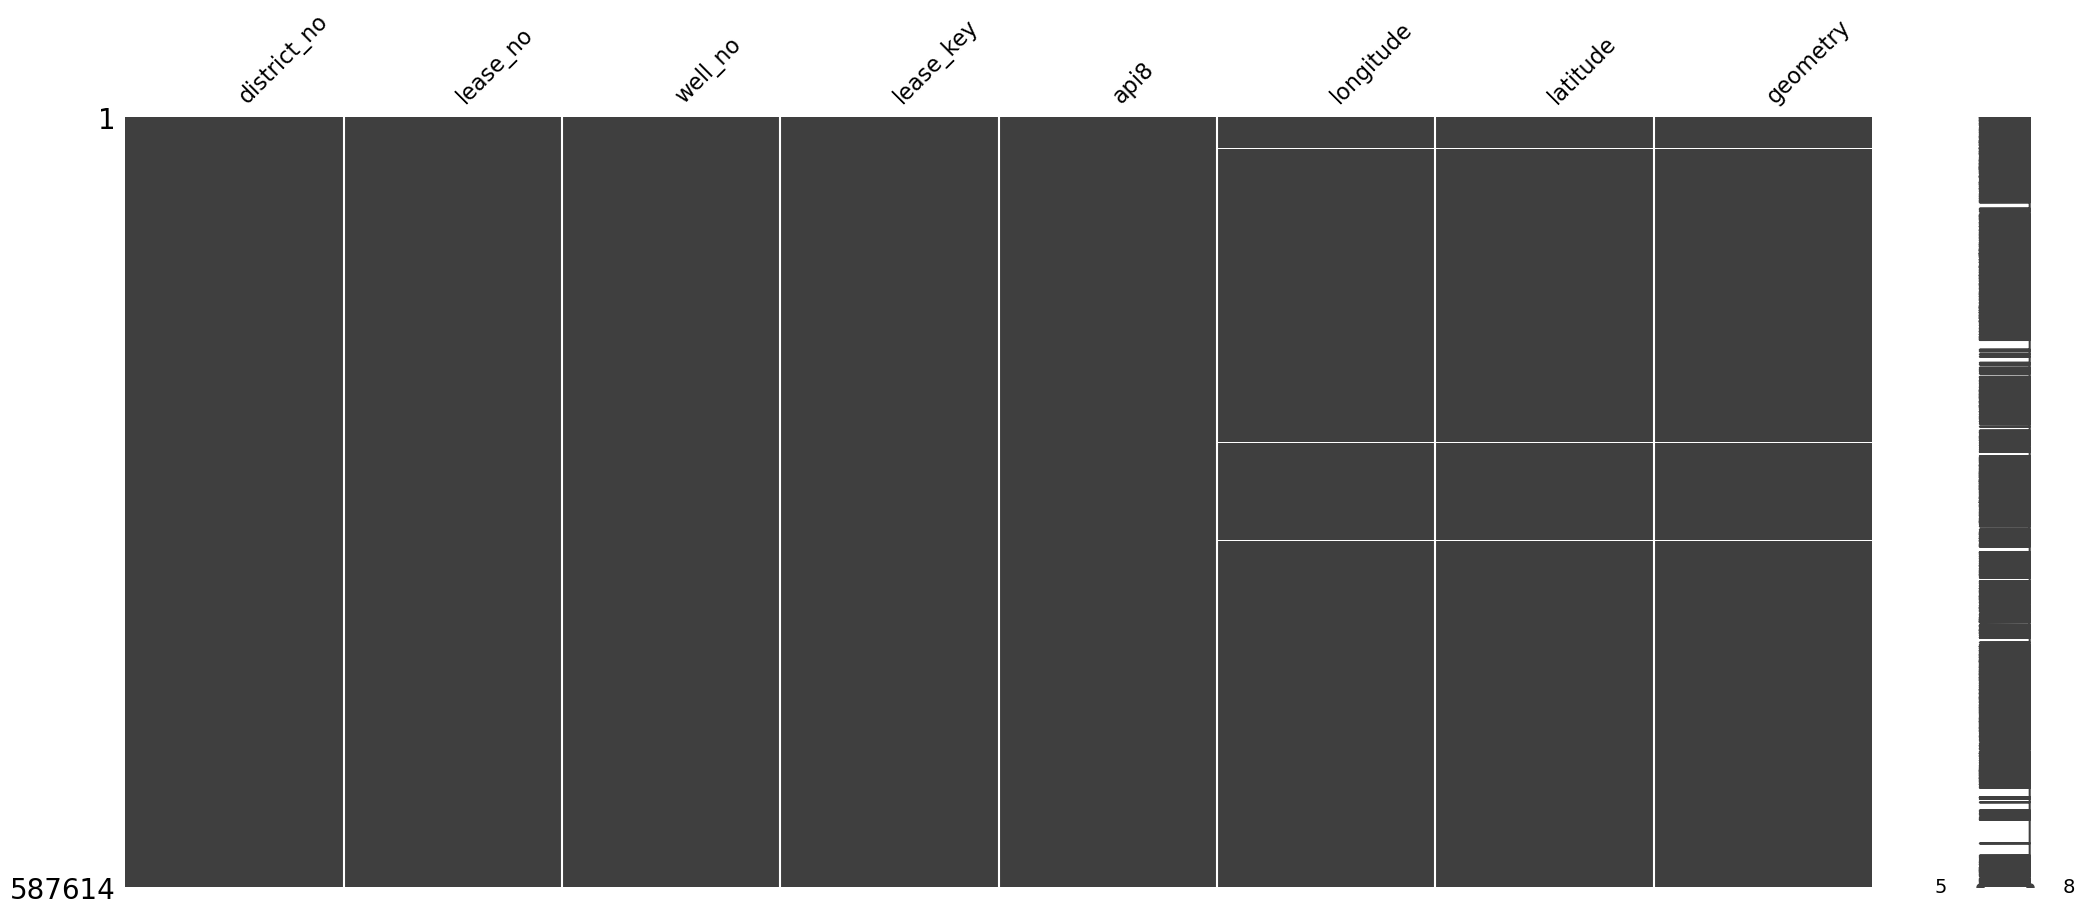

In [6]:
import missingno as msn
msn.matrix(gdf)

In [7]:
gdf.latitude.value_counts()

latitude
28.424716    10
28.795597     9
27.253851     9
33.729223     9
28.380347     9
             ..
31.866523     1
31.869089     1
31.86881      1
31.865819     1
32.045496     1
Name: count, Length: 504462, dtype: int64

In [8]:
leases_lon = gdf.groupby(['lease_key']).longitude.var()
leases_lat = gdf.groupby(['lease_key']).longitude.var()

lease_cord_var = ((leases_lat + leases_lon)**0.5)
lease_cord_var = lease_cord_var*float(111000)
lease_cord_var

lease_key
O_01_00001            NaN
O_01_00002     179.417363
O_01_00003     175.753667
O_01_00005      75.136704
O_01_00006            NaN
                 ...     
O_14_09885            NaN
O_14_09886            NaN
O_14_09887    1670.081906
O_14_09888            NaN
O_14_09889            NaN
Name: longitude, Length: 169866, dtype: object

In [9]:
nan_count = leases_lat.isna().sum()
print(f"NaN count: {nan_count}")

NaN count: 105272


In [10]:
s_clean = lease_cord_var.dropna()

s_clean.describe()

count     64594.0
unique    61755.0
top           0.0
freq       1731.0
Name: longitude, dtype: float64

Saved.


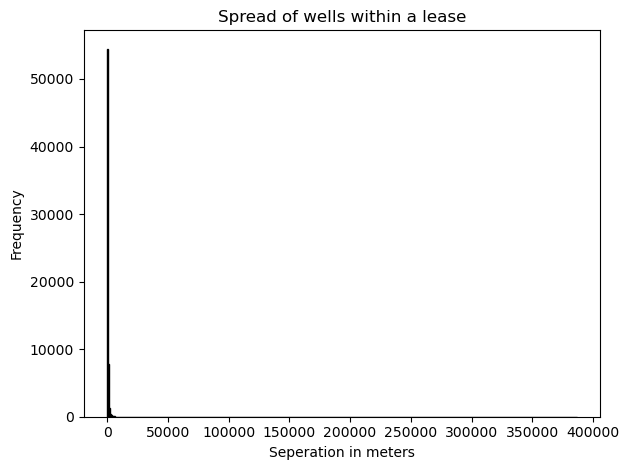

In [114]:
fig, ax = plt.subplots()
ax.hist(s_clean, bins='auto', edgecolor='black')
ax.set_title(f"Spread of wells within a lease")
ax.set_xlabel("Seperation in meters")
ax.set_ylabel("Frequency")
plt.tight_layout()
print("Saved.")

Saved.


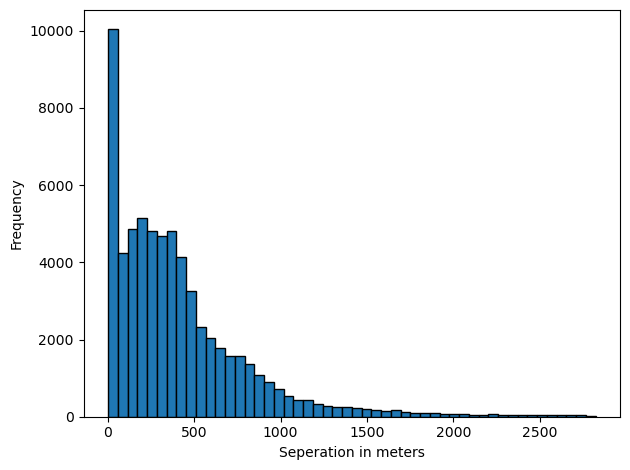

In [11]:
lower, upper = s_clean.quantile(0.01), s_clean.quantile(0.99)

fig, ax = plt.subplots()
ax.hist(s_clean, bins=50, range=(lower, upper), edgecolor='black')
ax.set_xlabel("Seperation in meters")
ax.set_ylabel("Frequency")
plt.tight_layout()
print("Saved.")

In [12]:
gdf2 = pd.read_parquet(path2)
gdf2.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'field_no',
       'lease_oil_prod_vol', 'lease_csgd_prod_vol', 'lease_csgd_tot_disp',
       'operator_no', 'operator_name', 'date', 'oil_gas_code_norm',
       'district_no_norm', 'lease_no_norm', 'lease_key',
       'n_wells_with_coordinates', 'county_name', 'lease_longitude',
       'lease_latitude'],
      dtype='str')

In [13]:
gdf2a = gdf2.drop(columns = ['oil_gas_code','oil_gas_code_norm',
       'district_no_norm', 'lease_no_norm','county_name']).copy()
print(gdf2a.shape)
gdf2a.columns


(19086019, 13)


Index(['district_no', 'lease_no', 'field_no', 'lease_oil_prod_vol',
       'lease_csgd_prod_vol', 'lease_csgd_tot_disp', 'operator_no',
       'operator_name', 'date', 'lease_key', 'n_wells_with_coordinates',
       'lease_longitude', 'lease_latitude'],
      dtype='str')

In [14]:
# Count how many NaN values exist in each column
gdf2a.isna().sum()



district_no                       0
lease_no                          0
field_no                          0
lease_oil_prod_vol                0
lease_csgd_prod_vol         6801693
lease_csgd_tot_disp               0
operator_no                       0
operator_name                     0
date                              0
lease_key                         0
n_wells_with_coordinates     158820
lease_longitude              158820
lease_latitude               158820
dtype: int64

In [16]:
gdf2a.shape

(19086019, 13)